In [1]:
!pip install scikit-learn tensorflow transformers torch datasets seaborn matplotlib

In [9]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [10]:
from datasets import load_dataset

dataset = load_dataset("imdb")

# Shuffle dataset
train_dataset_shuffled = dataset['train'].shuffle(seed=42)
test_dataset_shuffled = dataset['test'].shuffle(seed=42)

# Use more data
train_texts = train_dataset_shuffled['text'][:20000]
train_labels = train_dataset_shuffled['label'][:20000]

test_texts = test_dataset_shuffled['text'][:5000]
test_labels = test_dataset_shuffled['label'][:5000]

In [11]:
import time
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Better TF-IDF configuration
vectorizer = TfidfVectorizer(
    max_features=20000,      # larger vocabulary
    ngram_range=(1,2),       # unigram + bigram
    stop_words='english',    # remove common words
    min_df=3,                # remove rare noise words
    max_df=0.9               # ignore very frequent words
)

X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

print("Unique labels:", np.unique(train_labels))

start = time.time()

lr_model = LogisticRegression(
    max_iter=800,
    solver='liblinear'
)

lr_model.fit(X_train, train_labels)

lr_train_time = time.time() - start

lr_preds = lr_model.predict(X_test)

lr_acc = accuracy_score(test_labels, lr_preds)

print("Logistic Regression Accuracy:", lr_acc)
print("Training time:", lr_train_time)

Unique labels: [0 1]
Logistic Regression Accuracy: 0.8748
Training time: 0.7848377227783203


In [12]:
import time
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.metrics import accuracy_score

max_words = 10000
max_len = 300   # increased sequence length

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(train_texts)

X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_test_seq = tokenizer.texts_to_sequences(test_texts)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

start = time.time()

lstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(128),          # increased LSTM units
    Dropout(0.5),       # helps generalization
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.fit(
    X_train_pad,
    np.array(train_labels),
    epochs=3,           # increased epochs
    batch_size=64,
    validation_split=0.2
)

lstm_train_time = time.time() - start

lstm_preds = (lstm_model.predict(X_test_pad) > 0.5).astype(int)

lstm_acc = accuracy_score(test_labels, lstm_preds)

print("LSTM Accuracy:", lstm_acc)
print("Training time:", lstm_train_time)

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.6270 - loss: 0.6296 - val_accuracy: 0.8455 - val_loss: 0.3633
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8901 - loss: 0.2792 - val_accuracy: 0.8680 - val_loss: 0.3397
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9098 - loss: 0.2425 - val_accuracy: 0.8457 - val_loss: 0.5068
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
LSTM Accuracy: 0.829
Training time: 18.40060830116272


In [19]:
import time
import numpy as np
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score

model_name = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(model_name)

train_dataset = Dataset.from_dict({
    "text": train_texts,
    "label": train_labels
})

test_dataset = Dataset.from_dict({
    "text": test_texts,
    "label": test_labels
})

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128   # smaller length = faster training
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
test_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])

model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,                     # more epochs improves accuracy
    per_device_train_batch_size=32,         # larger batch = faster
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy="epoch",
    logging_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

start = time.time()

trainer.train()

bert_train_time = time.time() - start

preds = trainer.predict(test_dataset)

bert_preds = np.argmax(preds.predictions, axis=1)

bert_acc = accuracy_score(test_labels, bert_preds)

print("BERT Accuracy:", bert_acc)
print("Training time:", bert_train_time)

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.300445,0.280604
2,0.210387,0.282706
3,0.117197,0.362181


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT Accuracy: 0.8908
Training time: 1638.1523129940033


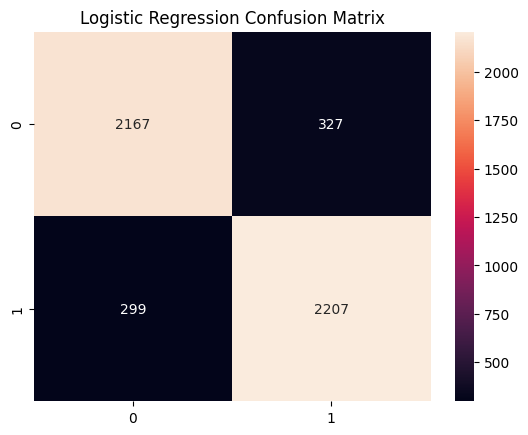

In [20]:
cm = confusion_matrix(test_labels, lr_preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

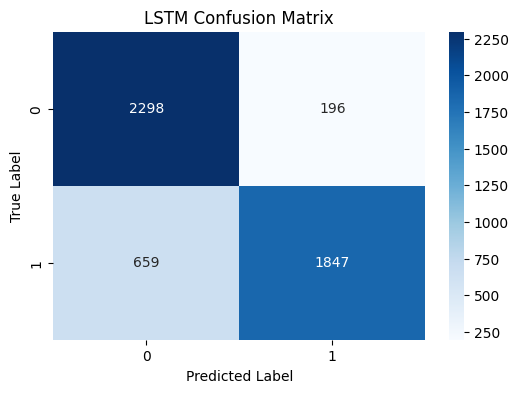

In [21]:

lstm_preds = lstm_preds.flatten()

cm_lstm = confusion_matrix(test_labels, lstm_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Blues")

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

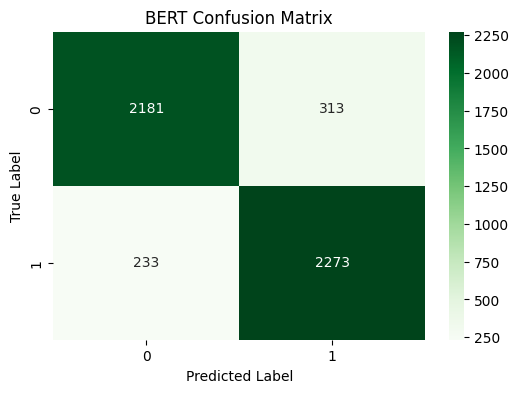

In [22]:
cm_bert = confusion_matrix(test_labels, bert_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Greens")

plt.title("BERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [24]:
print("Logistic Regression")
print(classification_report(test_labels, lr_preds))

print("LSTM")
print(classification_report(test_labels, lstm_preds))

print("BERT")
print(classification_report(test_labels, bert_preds))

Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      2494
           1       0.87      0.88      0.88      2506

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000

LSTM
              precision    recall  f1-score   support

           0       0.78      0.92      0.84      2494
           1       0.90      0.74      0.81      2506

    accuracy                           0.83      5000
   macro avg       0.84      0.83      0.83      5000
weighted avg       0.84      0.83      0.83      5000

BERT
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      2494
           1       0.88      0.91      0.89      2506

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89 

In [25]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","LSTM","BERT"],
    "Accuracy": [lr_acc, lstm_acc, bert_acc],
    "Training Time": [lr_train_time, lstm_train_time, bert_train_time]
})

print(results)

                 Model  Accuracy  Training Time
0  Logistic Regression    0.8748       0.784838
1                 LSTM    0.8290      18.400608
2                 BERT    0.8908    1638.152313


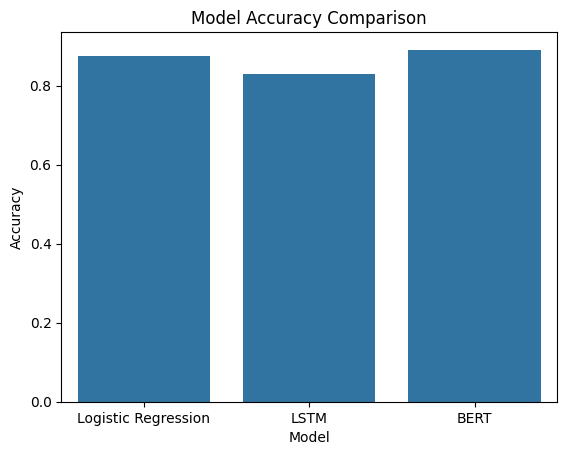

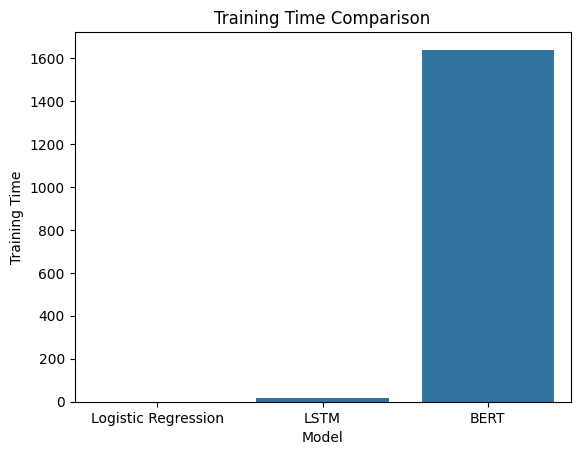

In [26]:
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Accuracy Comparison")
plt.show()

sns.barplot(x="Model", y="Training Time", data=results)
plt.title("Training Time Comparison")
plt.show()

In [28]:
import pandas as pd

lr_error_df = pd.DataFrame({
    "review": test_texts,
    "true_label": test_labels,
    "predicted_label": lr_preds
})

# False Positives
lr_fp = lr_error_df[
    (lr_error_df.true_label == 0) &
    (lr_error_df.predicted_label == 1)
]

# False Negatives
lr_fn = lr_error_df[
    (lr_error_df.true_label == 1) &
    (lr_error_df.predicted_label == 0)
]

print("Logistic Regression Errors")
print("False Positives:", len(lr_fp))
print("False Negatives:", len(lr_fn))

Logistic Regression Errors
False Positives: 327
False Negatives: 299


In [29]:
print("Example Logistic Regression Errors:\n")

for i in range(3):
    print("Review:", lr_fn.iloc[i]["review"][:400])
    print("True Label:", lr_fn.iloc[i]["true_label"])
    print("Predicted:", lr_fn.iloc[i]["predicted_label"])
    print("-"*80)

Example Logistic Regression Errors:

Review: This is a really sad, and touching movie! It deals with the subject of child abuse. It's really sad, but mostly a true story, because it happens everyday. Elijah Wood and Joseph Mazzello play the two children or Lorraine Bracco, a single mother who just tries to make a home for them. While living with her parents, a man, who likes to be called "The King" comes into their life. He hits the youngest
True Label: 1
Predicted: 0
--------------------------------------------------------------------------------
Review: Late night on BBC1, was on my way to bed but curiosity piqued at a contemporary-set Irish film so I stayed to watch for a few minutes and then stayed to the end. I have to admit that the main attraction was the only English actress, Kelly Reilly, who is stunning to look at.<br /><br />This is billed as a black comedy, which is one of the hardest things to pull off. It should be the perfect blend o
True Label: 1
Predicted: 0
----------

In [30]:
lstm_error_df = pd.DataFrame({
    "review": test_texts,
    "true_label": test_labels,
    "predicted_label": lstm_preds.flatten()
})

lstm_fp = lstm_error_df[
    (lstm_error_df.true_label == 0) &
    (lstm_error_df.predicted_label == 1)
]

lstm_fn = lstm_error_df[
    (lstm_error_df.true_label == 1) &
    (lstm_error_df.predicted_label == 0)
]

print("LSTM Errors")
print("False Positives:", len(lstm_fp))
print("False Negatives:", len(lstm_fn))

LSTM Errors
False Positives: 196
False Negatives: 659


In [31]:
print("Example LSTM Errors:\n")

for i in range(3):
    print("Review:", lstm_fn.iloc[i]["review"][:400])
    print("True Label:", lstm_fn.iloc[i]["true_label"])
    print("Predicted:", lstm_fn.iloc[i]["predicted_label"])
    print("-"*80)

Example LSTM Errors:

Review: This is the latest entry in the long series of films with the French agent, O.S.S. 117 (the French answer to James Bond). The series was launched in the early 1950's, and spawned at least eight films (none of which was ever released in the U.S.). 'O.S.S.117:Cairo,Nest Of Spies' is a breezy little comedy that should not...repeat NOT, be taken too seriously. Our protagonist finds himself in the midd
True Label: 1
Predicted: 0
--------------------------------------------------------------------------------
Review: After a very long time Marathi cinema has come with some good movie.This movie is one of the best Marathi movies ever made. It shows how a old grandfather tries to save his grandsons eye. He tries everything that is possible in his hands to save the child's eye. Doctor and a relative of his tries to help him in his attempt.<br /><br />The acting by the grandfather, the boy and the doctor are simpl
True Label: 1
Predicted: 0
-------------------------

In [32]:
bert_error_df = pd.DataFrame({
    "review": test_texts,
    "true_label": test_labels,
    "predicted_label": bert_preds
})

bert_fp = bert_error_df[
    (bert_error_df.true_label == 0) &
    (bert_error_df.predicted_label == 1)
]

bert_fn = bert_error_df[
    (bert_error_df.true_label == 1) &
    (bert_error_df.predicted_label == 0)
]

print("BERT Errors")
print("False Positives:", len(bert_fp))
print("False Negatives:", len(bert_fn))

BERT Errors
False Positives: 313
False Negatives: 233


In [33]:
print("Example BERT Errors:\n")

for i in range(3):
    print("Review:", bert_fn.iloc[i]["review"][:400])
    print("True Label:", bert_fn.iloc[i]["true_label"])
    print("Predicted:", bert_fn.iloc[i]["predicted_label"])
    print("-"*80)

Example BERT Errors:

Review: Late night on BBC1, was on my way to bed but curiosity piqued at a contemporary-set Irish film so I stayed to watch for a few minutes and then stayed to the end. I have to admit that the main attraction was the only English actress, Kelly Reilly, who is stunning to look at.<br /><br />This is billed as a black comedy, which is one of the hardest things to pull off. It should be the perfect blend o
True Label: 1
Predicted: 0
--------------------------------------------------------------------------------
Review: I'd like to point out these excellent points in favor of this movie:<br /><br />#1 Angelina Jolie sex scene <br /><br />#2 Foley artist outdid themselves <br /><br />#3 plot was quite thick <br /><br />#4 DVD does includes trailers and chapter stops<br /><br />#5 no animals were harmed in the making of the movie <br /><br />#6 homages to blade runner through out the film <br /><br />#7 burning tra
True Label: 1
Predicted: 0
-------------------------

In [34]:
error_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "LSTM", "BERT"],
    "False Positives": [len(lr_fp), len(lstm_fp), len(bert_fp)],
    "False Negatives": [len(lr_fn), len(lstm_fn), len(bert_fn)]
})

print(error_summary)

                 Model  False Positives  False Negatives
0  Logistic Regression              327              299
1                 LSTM              196              659
2                 BERT              313              233


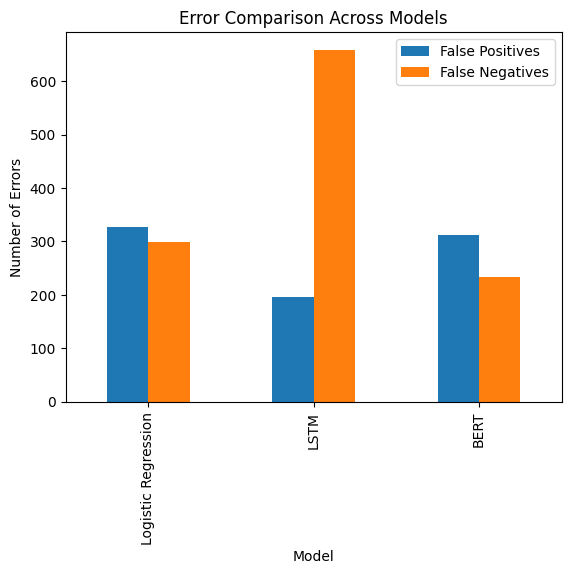

In [35]:
import matplotlib.pyplot as plt

error_summary.set_index("Model").plot(kind="bar")

plt.title("Error Comparison Across Models")
plt.ylabel("Number of Errors")
plt.xlabel("Model")

plt.show()

In [36]:
import random

def add_noise(text):
    words = text.split()
    random.shuffle(words)
    return " ".join(words)

noisy_test = [add_noise(t) for t in test_texts]

X_test_noise = vectorizer.transform(noisy_test)

noise_preds = lr_model.predict(X_test_noise)

print("Logistic Regression Accuracy on Noisy Data:",
      accuracy_score(test_labels, noise_preds))

Logistic Regression Accuracy on Noisy Data: 0.8702


In [39]:
from tensorflow.keras.preprocessing.text import Tokenizer

max_words = 10000

keras_tokenizer = Tokenizer(num_words=max_words)

# Fit tokenizer on training text
keras_tokenizer.fit_on_texts(train_texts)

In [40]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score

# Convert noisy text to sequences
noisy_seq = keras_tokenizer.texts_to_sequences(noisy_test)

# Pad sequences
X_test_noise_lstm = pad_sequences(noisy_seq, maxlen=max_len)

# Predict
lstm_noise_preds = (lstm_model.predict(X_test_noise_lstm) > 0.5).astype(int)

# Flatten predictions
lstm_noise_preds = lstm_noise_preds.flatten()

print("LSTM Accuracy on Noisy Data:",
      accuracy_score(test_labels, lstm_noise_preds))

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
LSTM Accuracy on Noisy Data: 0.8252


In [43]:
from transformers import BertTokenizer

bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [47]:
from sklearn.metrics import accuracy_score
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

batch_size = 16
bert_noise_preds = []

for i in range(0, len(noisy_test), batch_size):

    batch_texts = noisy_test[i:i+batch_size]

    encoded = bert_tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded)

    preds = torch.argmax(outputs.logits, dim=1)

    bert_noise_preds.extend(preds.cpu().numpy())

print("BERT Accuracy on Noisy Data:",
      accuracy_score(test_labels, bert_noise_preds))

BERT Accuracy on Noisy Data: 0.8136


In [48]:
import pandas as pd
from sklearn.metrics import accuracy_score

noise_results = pd.DataFrame({
    "Model": ["Logistic Regression", "LSTM", "BERT"],
    "Noisy Accuracy": [
        accuracy_score(test_labels, noise_preds),
        accuracy_score(test_labels, lstm_noise_preds),
        accuracy_score(test_labels, bert_noise_preds)
    ]
})

print(noise_results)

                 Model  Noisy Accuracy
0  Logistic Regression          0.8702
1                 LSTM          0.8252
2                 BERT          0.8136


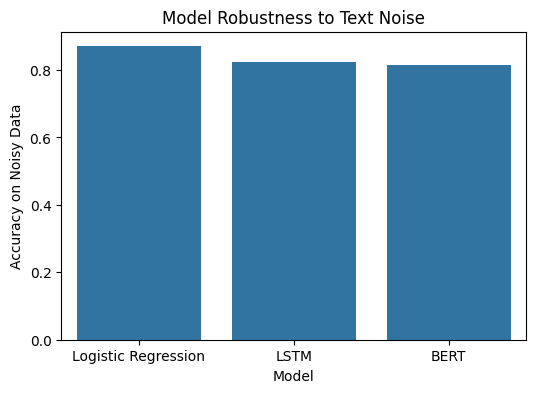

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.barplot(
    x="Model",
    y="Noisy Accuracy",
    data=noise_results
)

plt.title("Model Robustness to Text Noise")
plt.ylabel("Accuracy on Noisy Data")
plt.xlabel("Model")

plt.show()